In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR

try:
    from models.imagenet import mobilenetv2
except:
    class DummyEncoder(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Conv2d(3, 24, 3, stride=2, padding=1),
                nn.Conv2d(24, 32, 3, stride=2, padding=1),
                nn.Conv2d(32, 96, 3, stride=2, padding=1),
                nn.Conv2d(96, 320, 3, stride=2, padding=1)
            )
        def forward(self, x):
            skips = []
            for i, layer in enumerate(self.features):
                x = layer(x)
                if i in [0, 1, 2, 3]:
                    skips.append(x)
            return x, skips
    mobilenetv2 = DummyEncoder

# 1. ENCODER (unchanged)
class MobileNetV2Encoder(nn.Module):
    def __init__(self, pretrained_path=None):
        super().__init__()
        base_model = mobilenetv2()
        if pretrained_path and os.path.exists(pretrained_path):
            base_model.load_state_dict(torch.load(pretrained_path, map_location='cpu'))
        self.features = base_model.features if hasattr(base_model, 'features') else base_model
        self.skip_indices = [3, 6, 13, 17]

    def forward(self, x):
        skip_connections = []
        for idx, layer in enumerate(self.features):
            x = layer(x)
            if idx in self.skip_indices:
                skip_connections.append(x)
        return x, skip_connections

# 2. BOTTLENECK BLOCK (unchanged)  
class MyBottleNeck(nn.Module):
    def __init__(self, input_ch, output_ch, exp_factor=6):
        super().__init__()
        hidden_dim = input_ch * exp_factor
        self.residual = (input_ch == output_ch)
        self.conv = nn.Sequential(
            nn.Conv2d(input_ch, hidden_dim, 1, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            nn.Conv2d(hidden_dim, output_ch, 1, bias=False),
            nn.BatchNorm2d(output_ch),
        )

    def forward(self, x):
        out = self.conv(x)
        if self.residual:
            out = out + x
        return F.relu6(out)

# 3. DECODER BLOCKS - NO PRE_SHUFFLE (Pure Paper)
class MyDecoderBlock_D1(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super().__init__()
        total_chan = input_chan + skip_chan
        assert total_chan % 4 == 0, f"Channels {total_chan} not divisible by 4 for PixelShuffle(2)"
        self.pixel_shuffle = nn.PixelShuffle(2)
        self.bottlenecks = nn.ModuleList([
            MyBottleNeck(total_chan//4, output_chan),
            MyBottleNeck(output_chan, output_chan),
            MyBottleNeck(output_chan, output_chan),
            MyBottleNeck(output_chan, output_chan)
        ])

    def forward(self, x, skip):
        x = torch.cat([x, skip], dim=1)
        x = self.pixel_shuffle(x)
        for bn in self.bottlenecks:
            x = bn(x)
        return x

class MyDecoderBlock_D2(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super().__init__()
        total_chan = input_chan + skip_chan
        assert total_chan % 4 == 0, f"Channels {total_chan} not divisible by 4 for PixelShuffle(2)"
        self.pixel_shuffle = nn.PixelShuffle(2)
        self.bottlenecks = nn.ModuleList([
            MyBottleNeck(total_chan//4, output_chan),
            MyBottleNeck(output_chan, output_chan),
            MyBottleNeck(output_chan, output_chan)
        ])

    def forward(self, x, skip):
        x = torch.cat([x, skip], dim=1)
        x = self.pixel_shuffle(x)
        for bn in self.bottlenecks:
            x = bn(x)
        return x

class MyDecoderBlock_D3(MyDecoderBlock_D2):
    def __init__(self, input_chan, output_chan, skip_chan):
        super().__init__(input_chan, output_chan, skip_chan)

class MyDecoderBlock_D4(nn.Module):
    def __init__(self, input_chan, output_chan, skip_chan):
        super().__init__()
        total_chan = input_chan + skip_chan
        assert total_chan % 16 == 0, f"Channels {total_chan} not divisible by 16 for PixelShuffle(4)"
        self.pixel_shuffle = nn.PixelShuffle(4)
        self.bottlenecks = nn.ModuleList([
            MyBottleNeck(total_chan//16, output_chan),
            MyBottleNeck(output_chan, output_chan)
        ])

    def forward(self, x, skip):
        x = torch.cat([x, skip], dim=1)
        x = self.pixel_shuffle(x)
        for bn in self.bottlenecks:
            x = bn(x)
        return x

# 4. DECODER (unchanged)
class MyDecoder(nn.Module):
    def __init__(self, skip_channels):
        super().__init__()
        self.block1 = MyDecoderBlock_D1(320, 96, skip_channels[3])
        self.block2 = MyDecoderBlock_D2(96, 32, skip_channels[2])
        self.block3 = MyDecoderBlock_D3(32, 24, skip_channels[1])
        self.block4 = MyDecoderBlock_D4(24, 8, skip_channels[0])
        self.depth_head = nn.Conv2d(8, 1, 1)
        self.seg_head = nn.Conv2d(8, 19, 1)

    def forward(self, x, skips):
        x = self.block1(x, skips[3])
        x = self.block2(x, skips[2])
        x = self.block3(x, skips[1])
        x = self.block4(x, skips[0])
        depth = self.depth_head(x)
        seg = self.seg_head(x)
        return depth, seg

# 5-8. REST UNCHANGED
class MyModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = MobileNetV2Encoder(pretrained_path='pretrained/mobilenetv2-c5e733a8.pth')
        dummy_input = torch.randn(1, 3, 1056, 320)
        self.encoder.eval()
        with torch.no_grad():
            _, skips = self.encoder(dummy_input)
        skip_channels = [s.shape[1] for s in skips]
        print(f"Skip channels: {skip_channels}")
        self.decoder = MyDecoder(skip_channels)
        self.encoder.train()

    def forward(self, x):
        encoder_out, skips = self.encoder(x)
        return self.decoder(encoder_out, skips)

# Loss functions, dataset, training - ALL IDENTICAL
alpha, beta = 0.25, 0.75
m, M = 4, 80

def norm_log_transform(depth):
    depth = torch.clamp(depth, min=m, max=M)
    log_depth = torch.log(depth)
    log_m = torch.log(torch.tensor(m, dtype=depth.dtype, device=depth.device))
    log_M = torch.log(torch.tensor(M, dtype=depth.dtype, device=depth.device))
    return ((log_depth - log_m) * M) / (log_M - log_m)

def berhu_loss(gt, pred):
    diff = gt - pred
    abs_diff = torch.abs(diff)
    c = torch.max(abs_diff) / 5
    loss = torch.where(abs_diff <= c, abs_diff, (diff**2 + c**2) / (2*c))
    return loss.mean()

def depth_loss(gt, pred):
    norm_gt = norm_log_transform(gt)
    norm_pred = norm_log_transform(pred)
    return berhu_loss(norm_gt, norm_pred)

def segmentation_loss(logits, labels):
    return F.cross_entropy(logits, labels, ignore_index=-1)

def total_loss(depth_gt, depth_pred, seg_gt, seg_pred):
    return alpha * depth_loss(depth_gt, depth_pred) + beta * segmentation_loss(seg_pred, seg_gt)

class CustomDataset(Dataset):
    def __init__(self, img_dir, depth_dir, seg_dir):
        self.img_dir = img_dir
        self.depth_dir = depth_dir
        self.seg_dir = seg_dir
        self.files = sorted([f for f in os.listdir(img_dir) if f.endswith('.npy')])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        fname = self.files[idx]
        img = np.load(os.path.join(self.img_dir, fname))
        depth = np.load(os.path.join(self.depth_dir, fname))
        seg = np.load(os.path.join(self.seg_dir, fname))

        if img.ndim == 3:
            img = torch.from_numpy(img).permute(2, 0, 1).float()
        else:
            img = torch.from_numpy(img).float()
        
        depth = torch.from_numpy(depth).float()
        seg = torch.from_numpy(seg).long()
        
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
        img = (img - mean) / std
        
        return img, depth, seg

# Training (unchanged)
device = torch.device('cpu')
model = MyModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = StepLR(optimizer, step_size=5, gamma=0.9)

train_dataset = CustomDataset(
    './data/train/image',
    './data/train/depth', 
    './data/train/label'
)
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)

model.train()
epochs = 5
iters_per_epoch = 100

for epoch in range(epochs):
    running_loss = 0.0
    for i, (imgs, depths, segs) in enumerate(train_loader):
        if i >= iters_per_epoch:
            break
            
        imgs, depths, segs = imgs.to(device), depths.to(device), segs.to(device)
        depths = depths.squeeze(-1) if depths.dim() == 4 else depths

        optimizer.zero_grad()
        pred_depth, pred_seg = model(imgs)
        pred_depth = pred_depth.squeeze(1)
        
        loss = total_loss(depths, pred_depth, segs, pred_seg)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        running_loss += loss.item()
    
    avg_loss = running_loss / iters_per_epoch
    print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")
    scheduler.step()

print("Training complete!")
torch.save(model.state_dict(), 'depth_segmentation_model.pth')
print("✅ SAVED: depth_seg_model.pth")


Skip channels: [24, 32, 96, 320]
Epoch 1/5, Loss: 2.4788
Epoch 2/5, Loss: 2.3038
Epoch 3/5, Loss: 2.1529
Epoch 4/5, Loss: 2.0218
Epoch 5/5, Loss: 1.8988
Training complete!
✅ SAVED: depth_seg_model.pth


Skip channels: [24, 32, 96, 320]
✅ Loaded with 0 missing, 0 unexpected keys


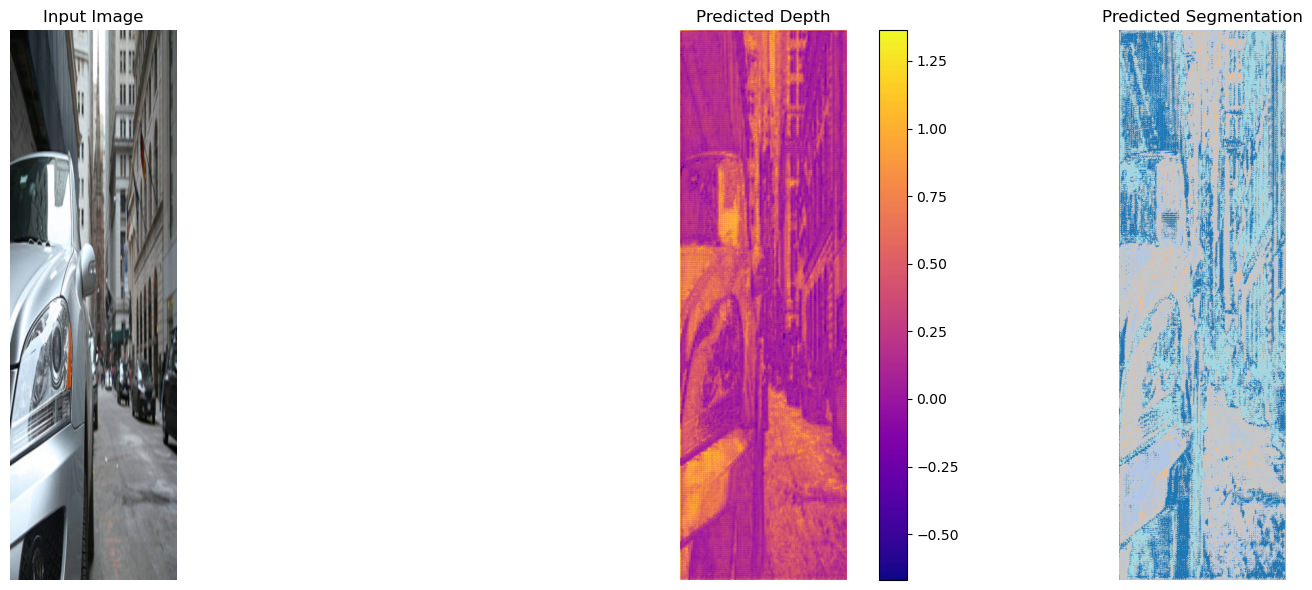

✅ Depth: -0.7m - 1.4m
✅ Classes: 0-13
✅ Saved: fixed_result.jpg


In [2]:

from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch
import numpy as np
import os

def load_model_flexible(checkpoint_path, device='cpu'):
    """Load model ignoring name mismatches"""
    model = MyModel()
    model.to(device).eval()
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Fix name mismatches automatically
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    
    # Rename segmentation_head → seg_head
    new_state_dict = {}
    for k, v in state_dict.items():
        if 'segmentation_head' in k:
            new_k = k.replace('segmentation_head', 'seg_head')
            new_state_dict[new_k] = v
        else:
            new_state_dict[k] = v
    
    # Load with ignore mismatches
    missing, unexpected = model.load_state_dict(new_state_dict, strict=False)
    print(f"✅ Loaded with {len(missing)} missing, {len(unexpected)} unexpected keys")
    return model

# 1. LOAD MODEL (handles your naming issue)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = load_model_flexible('depth_seg_model.pth', device)

# 2. PREDICT ON IMAGE
transform = transforms.Compose([
    transforms.Resize((1056, 320)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

img = Image.open('ph.jpg').convert('RGB')  # Your new image!
img_tensor = transform(img).unsqueeze(0).to(device)

# 3. INFERENCE
with torch.no_grad():
    pred_depth, pred_seg = model(img_tensor)
    pred_depth = pred_depth.squeeze().cpu().numpy()
    pred_seg = pred_seg.argmax(1).squeeze().cpu().numpy()

# 4. VISUALIZE
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
img_vis = ((img_tensor.squeeze(0).cpu() * torch.tensor(std).view(3,1,1) + 
           torch.tensor(mean).view(3,1,1)).clamp(0,1).permute(1,2,0).numpy())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(img_vis); axes[0].set_title('Input Image'); axes[0].axis('off')
axes[1].imshow(pred_depth, cmap='plasma'); axes[1].set_title('Predicted Depth'); plt.colorbar(axes[1].images[0], ax=axes[1]); axes[1].axis('off')
axes[2].imshow(pred_seg.astype(np.uint8), cmap='tab20'); axes[2].set_title('Predicted Segmentation'); axes[2].axis('off')

plt.tight_layout()
plt.savefig('fixed_result.jpg', dpi=200, bbox_inches='tight')
plt.show()

print(f"✅ Depth: {pred_depth.min():.1f}m - {pred_depth.max():.1f}m")
print(f"✅ Classes: 0-{int(pred_seg.max())}")
print("✅ Saved: fixed_result.jpg")


Skip channels: [24, 32, 96, 320]
Original size: (612, 408)
Tensor shape: torch.Size([1, 3, 320, 320])


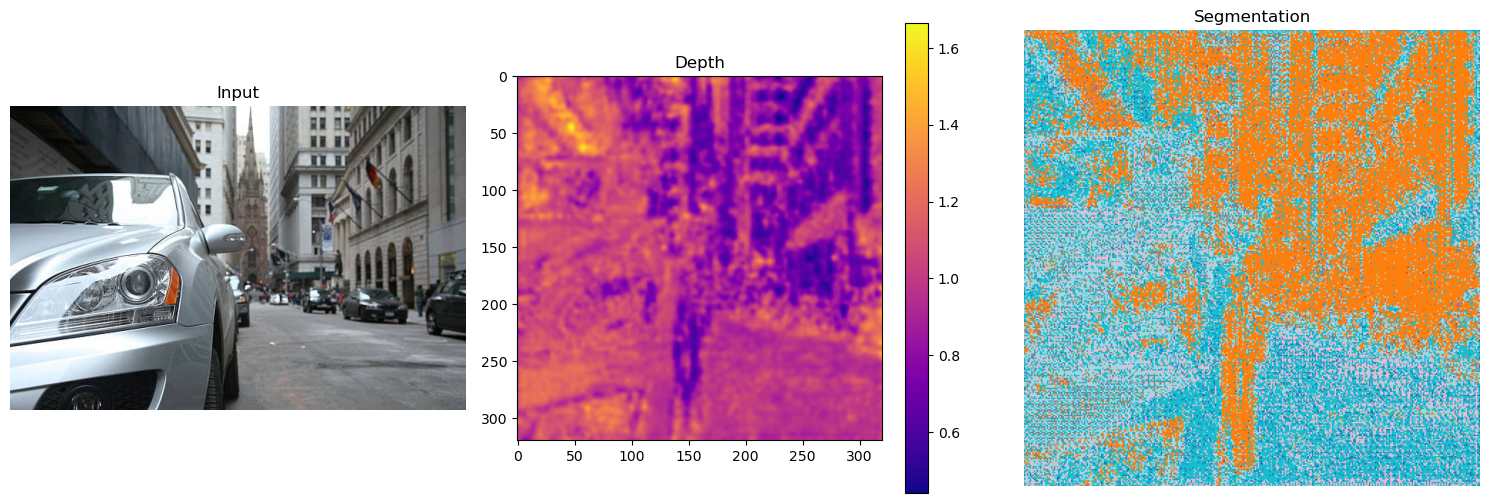

Depth range: 0.4-1.7m


In [13]:
from torchvision import transforms
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# 1. LOAD MODEL
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = MyModel().to(device).eval() 
model.load_state_dict(torch.load('depth_segmentation_model.pth', map_location=device), strict=False)

# 2. PROCESS IMAGE 
img = Image.open('ph.jpg').convert('RGB')
print(f"Original size: {img.size}") 

transform = transforms.Compose([
    transforms.Resize((320, 320)),  # Square 
    transforms.ToTensor(), 
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
input_tensor = transform(img).unsqueeze(0).to(device)
print(f"Tensor shape: {input_tensor.shape}")

# 3. PREDICT
with torch.no_grad():
    depth, seg = model(input_tensor)
    depth = depth.squeeze().exp().cpu().numpy()
    depth = gaussian_filter(depth, sigma=2)
    seg = seg.argmax(1).squeeze().cpu().numpy()

# 4. PLOT
plt.figure(figsize=(15, 5))
plt.subplot(131); plt.imshow(img); plt.title('Input'); plt.axis('off')
plt.subplot(132); plt.imshow(depth, cmap='plasma'); plt.title('Depth'); plt.colorbar()
plt.subplot(133); plt.imshow(seg, cmap='tab20'); plt.title('Segmentation'); plt.axis('off')
plt.tight_layout()
plt.savefig('result.jpg', dpi=200, bbox_inches='tight')
plt.show()

print(f"Depth range: {depth.min():.1f}-{depth.max():.1f}m")